In [ ]:
import pandas as pd 

df = pd.read_csv ("../data/AqSolDB_v1.0_min.csv")
df.head()

,ID,Name,InChIKey,SMILES,Solubility
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065


In [8]:
df.shape


(9982, 5)

In [9]:
df.columns

Index(['ID', 'Name', 'InChIKey', 'SMILES', 'Solubility'], dtype='str')

In [10]:
from rdkit import Chem

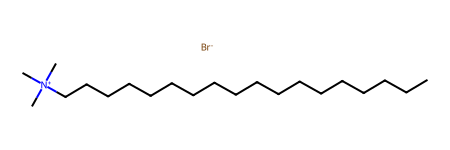

In [11]:
smiles = df["SMILES"][0]
mol = Chem.MolFromSmiles(smiles)
mol

In [12]:
print(type(mol))


<class 'rdkit.Chem.rdchem.Mol'>


In [13]:
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)

[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not removing hydrogen atom without neighbors
[13:56:07] WARNING: not r

In [14]:
df[["SMILES", "Name"]].head()

,SMILES,Name
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,"N,N,N-trimethyloctadecan-1-aminium bromide"
1,O=C1Nc2cccc3cccc1c23,Benzo[cd]indol-2(1H)-one
2,Clc1ccc(C=O)cc1,4-chlorobenzaldehyde
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo..."
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...


In [15]:
df["Name"].isnull().sum()

np.int64(0)

In [16]:
from rdkit.Chem import rdFingerprintGenerator

In [17]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprint = morgan_generator.GetFingerprint(mol)

fingerprint

In [18]:
len(fingerprint)

2048

In [19]:
list(fingerprint)[:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [21]:
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)

print("Invalid molecules:", df["mol"].isnull().sum())

df = df.dropna(subset=["mol"]).reset_index(drop=True)

print("Clean dataset shape:", df.shape)

[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not removing hydrogen atom without neighbors
[14:00:52] WARNING: not r

Invalid molecules: 2
Clean dataset shape: (9980, 6)


[14:00:53] WARNING: not removing hydrogen atom without neighbors
[14:00:53] WARNING: not removing hydrogen atom without neighbors


In [23]:
from rdkit.Chem import Descriptors, rdMolDescriptors
import numpy as np

def mol_to_features(mol):
    fingerprint = morgan_generator.GetFingerprint(mol)
    fingerprint_array = np.array(fingerprint)

    descriptors = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRings(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),

        Descriptors.HeavyAtomCount(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        Descriptors.MolMR(mol),
        Descriptors.BertzCT(mol),
        rdMolDescriptors.CalcLabuteASA(mol),
        rdMolDescriptors.CalcNumHeteroatoms(mol),
        Chem.GetFormalCharge(mol),
    ])

    return np.concatenate([fingerprint_array, descriptors])

X = np.array([mol_to_features(mol) for mol in df["mol"]])
y = df["Solubility"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9980, 2064)
y shape: (9980,)


In [24]:
print(X[1][:20])
print(y[1])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
-3.2547670983


In [25]:
# tarining  of data for   model

from sklearn.model_selection import train_test_split

X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7984, 2064)
X_test: (1996, 2064)
y_train: (7984,)
y_test: (1996,)


In [17]:
# train first model  Random Forest :

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete")

KeyboardInterrupt: 

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Random Forest Results
MAE: 0.5142536891592923
RMSE: 0.7532705340271668
R²: 0.8799576714590173


In [27]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        random_state=42
    ),
    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42
    )
}

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="RMSE")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5230
[LightGBM] [Info] Number of data points in the train set: 7984, number of used features: 1637
[LightGBM] [Info] Start training from score -2.889159


/workspaces/Molecular-Prediction/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MAE,RMSE,R2
5,LightGBM,0.688865,1.000398,0.815405
4,XGBoost,0.694028,1.014129,0.810303
2,Random Forest,0.673242,1.014566,0.810140
3,Gradient Boosting,0.782104,1.098034,0.777615
1,Ridge Regression,1.064146,1.491016,0.589949
0,Linear Regression,1.097114,1.533852,0.566049
6,Neural Network,1.062834,1.591151,0.533022


In [28]:
import joblib

best_model = models["LightGBM"]

joblib.dump(best_model, "../models/best_model.pkl")

print("New best model saved")

New best model saved


In [29]:
loaded_model = joblib.load("../models/best_model.pkl")

prediction = loaded_model.predict(X_test[:1])

print("Prediction:", prediction)
print("Actual:", y_test[:1])

Prediction: [-4.78936963]
Actual: [-5.9842425]


/workspaces/Molecular-Prediction/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [63]:
df[df["smiles"] == "CCO"]

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
983,Ethanol,0.02,1,46.069,1,0,0,20.23,1.1,CCO,<rdkit.Chem.rdchem.Mol object at 0x739476323bc0>


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
835,Benzene,-2.418,2,78.114,0,1,0,0.0,-1.64,c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x739476327d10>
